# Kenya Maize: EDA & Feature Engineering

**Input:** `data/cleaned/kenya_maize_cleaned.csv` (23,674 × 120) — the output of notebook 01.

**Scope:** CRISP-DM §3.3 *Feature Construction* and §3.5 *Train/Validation/Test Split Strategy*, for Kenya maize. No modeling happens here; this notebook produces the feature matrix and the **contract** the modeling package will consume.

**What this notebook does:**
1. Audits the cleaned data for the specific ways a feature can *look* usable and not be — target leakage, survey-instrument drift, contradicted fields, post-season measurements masquerading as planting choices (§1).
2. Applies the feature pipeline by calling the same functions used in `scripts/build_features.py`, so this notebook and the script can never drift apart (§2).
3. Saves two feature files, a manifest, and an audit-stats JSON (§3).

**Governing principle.** Notebook 01's rule was *never silently discard or overwrite a source value*. This notebook's rule is narrower and different:

> **Never emit a feature that cannot mean the same thing in the training years and in the holdout year.**

Kenya's survey instrument rotates modules year to year. A column that is 100% present in 2018 and 0% present in 2016 is not a feature with missing values — it is a year label wearing a feature's name. Every screen below exists to catch one specific way that failure happens.

**Companion documents:**
- `documentation/kenya_maize_feature_engineering_documentation.md` — the narrative write-up of every decision below.
- `scripts/build_features.py` — the standalone, re-runnable pipeline (`python scripts/build_features.py`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEANED_PATH = ROOT / "data" / "cleaned" / "kenya_maize_cleaned.csv"
SCRIPTS_DIR = ROOT / "scripts"

df = pd.read_csv(CLEANED_PATH, low_memory=False)
df["plant_date"] = pd.to_datetime(df["plant_date"], errors="coerce")
df["harvest_date"] = pd.to_datetime(df["harvest_date"], errors="coerce")

TARGET = "yield_kg_ph"
HOLDOUT_YEAR = 2020
train, holdout = df[df["year"] < HOLDOUT_YEAR], df[df["year"] == HOLDOUT_YEAR]

print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Train years 2016-2019: {len(train):,} rows  |  Holdout 2020: {len(holdout):,} rows")

Cleaned dataset: 23,674 rows x 119 columns
Train years 2016-2019: 17,484 rows  |  Holdout 2020: 6,190 rows


## 1. What can actually become a feature

### 1.1 The coverage matrix is the whole story

The CRISP-DM report (§3.5) specifies an out-of-time holdout: train on the earlier years, report the headline number on the most recent one — Kenya 2020. That is the right validation design, and it is exactly what makes survey-instrument drift dangerous rather than merely annoying.

Notebook 01 established that the survey questionnaire changes year to year. The question here is sharper: *for each column, is it present in the years I train on **and** the year I score on?* A single pooled "coverage across 2016–2019" number cannot answer that, because pooling averages over the very thing being asked about.

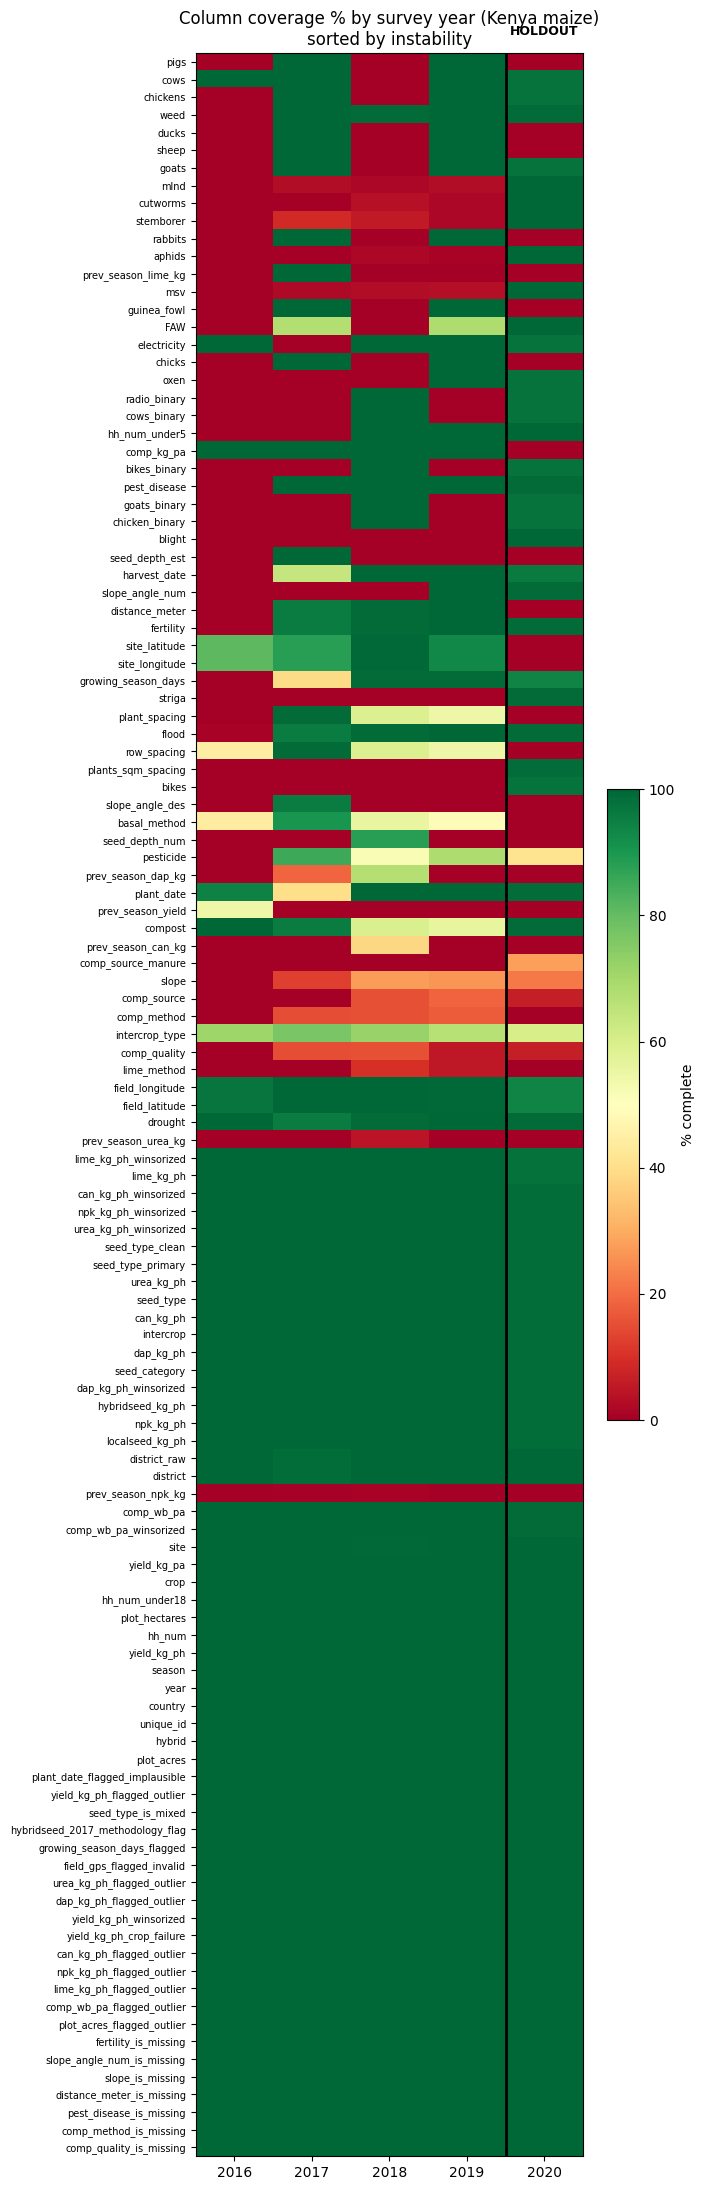

In [2]:
years = sorted(df["year"].unique())
cov = pd.DataFrame({y: df[df["year"] == y].notna().mean() * 100 for y in years})

# Order columns by how much their coverage swings across years -- the most
# unstable columns rise to the top, which is what we need to see.
cov = cov.loc[(cov.max(axis=1) - cov.min(axis=1)).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, 22))
im = ax.imshow(cov.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(years)), years)
ax.set_yticks(range(len(cov)), cov.index, fontsize=7)
ax.set_title("Column coverage % by survey year (Kenya maize)\nsorted by instability")
ax.axvline(3.5, color="black", linewidth=2)          # train | holdout boundary
ax.text(4.0, -1.5, "HOLDOUT", ha="center", fontsize=9, fontweight="bold")
fig.colorbar(im, ax=ax, label="% complete", shrink=0.3)
plt.tight_layout()
plt.show()

In [3]:
# The 60% threshold used by the pipeline, applied two ways:
THRESH = 60.0
pooled_train_cov = train.notna().mean() * 100

passes_pooled = (pooled_train_cov >= THRESH) & (cov[HOLDOUT_YEAR] >= THRESH)
zero_in_a_train_year = (cov[[2016, 2017, 2018, 2019]] < THRESH).any(axis=1)

trap = pd.DataFrame({
    "pooled_train_%": pooled_train_cov.round(1),
    **{f"cov_{y}": cov[y].round(1) for y in years},
})[passes_pooled & zero_in_a_train_year]

print(f"Columns that PASS a pooled train/holdout screen but are below {THRESH:.0f}% "
      f"in at least one individual train year:\n")
print(trap.sort_values("cov_2016").to_string())

Columns that PASS a pooled train/holdout screen but are below 60% in at least one individual train year:

                     pooled_train_%  cov_2016  cov_2017  cov_2018  cov_2019  cov_2020
fertility                      76.6       0.0      95.3      99.2     100.0      99.2
pest_disease                   77.8       0.0     100.0     100.0     100.0      99.2
harvest_date                   69.5       0.0      63.7     100.0     100.0      96.1
growing_season_days            63.5       0.0      39.4      99.1      99.2      94.0
weed                           77.6       0.0     100.0      99.2      99.9      99.1
flood                          76.8       0.9      95.3      99.2     100.0      99.2
plant_date                     84.9      94.2      39.9      99.7      99.8      98.5
electricity                    77.2     100.0       0.0     100.0     100.0      97.3
cows                           75.7     100.0     100.0       0.0     100.0      97.3
compost                        75.

**Finding — 2016 is a reduced survey instrument, not a normal year.** The columns above all clear a pooled screen while being *entirely absent* from one training year. `fertility`, `pest_disease`, `weed`, `chickens`, `goats`, `hh_num_under5`, `FAW` and `growing_season_days` are all **0% in 2016** (and `flood` is 0.9%), yet their pooled 2016–2019 coverage still reads 70–75% because the other three years carry them.

Handed to a gradient-boosted tree, this is not a missing-value problem — it is a free year label. The model learns *"`fertility` is null ⇒ this is 2016 ⇒ predict 2,822 kg/ha"* and books it as agronomy. That is a real effect (2016 genuinely is the lowest-yielding year) attributed to entirely the wrong cause, and it will not transfer.

This drives **Gate B** (a column must clear the threshold in ≥2 *individual* training years, not in the pooled average) and **Gate C** (see §2.6): for columns whose only failing year is 2016, drop the 2016 **rows** rather than the columns.

### 1.2 The target across the split boundary

        mean  median     std  size  zero_yield_rows
year                                               
2016  2822.0  2621.0  1544.0  3876               51
2017  3507.0  3303.0  1806.0  3991               49
2018  3184.0  2917.0  1649.0  4245               18
2019  3127.0  2903.0  1787.0  5372              121
2020  3120.0  2965.0  1591.0  6190               87


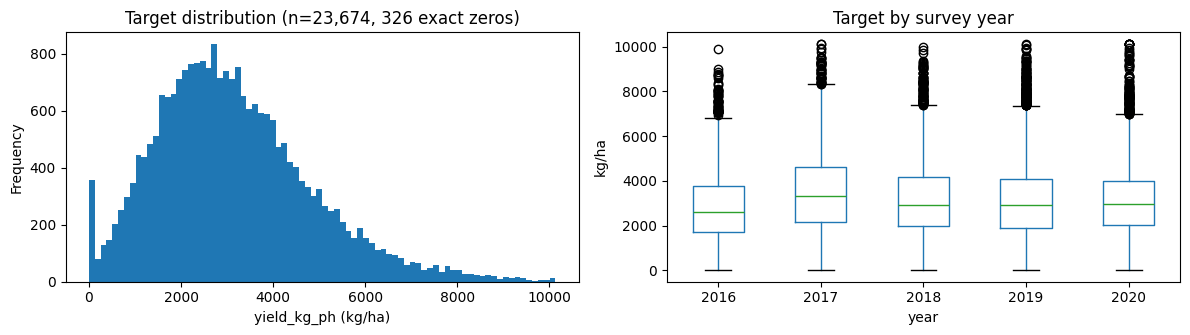

In [4]:
by_year = df.groupby("year")[TARGET].agg(["mean", "median", "std", "size"]).round(0)
by_year["zero_yield_rows"] = df[df[TARGET] == 0].groupby("year").size()
print(by_year.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
df[TARGET].plot.hist(bins=80, ax=axes[0])
axes[0].set_xlabel("yield_kg_ph (kg/ha)")
axes[0].set_title(f"Target distribution (n={len(df):,}, {(df[TARGET]==0).sum()} exact zeros)")

df.boxplot(column=TARGET, by="year", ax=axes[1], grid=False)
axes[1].set_title("Target by survey year")
axes[1].set_xlabel("year"); axes[1].set_ylabel("kg/ha")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Findings.** 2016 is the lowest-yielding year (mean 2,822 kg/ha against 3,120–3,507 for the rest) **and** the year with the stripped-down questionnaire. Those two facts are confounded, and nothing in this dataset can separate them — which is the second reason Gate C emits both a with-2016 and a without-2016 feature file rather than picking one.

The holdout year (2020, mean 3,120) sits comfortably inside the range of the training years, so the out-of-time split is not being asked to extrapolate to an unprecedented season. That is worth confirming rather than assuming: an out-of-time holdout on an anomalous year would report a pessimistic number for reasons unrelated to the model.

The target is right-skewed with 326 exact zeros (true crop failures, preserved by notebook 01). **This is recorded, not acted on here:** whether to model `log1p(yield)`, and whether the zeros deserve a separate crop-failure classification head, are modeling-time decisions. Feature engineering should not quietly commit to either.

### 1.3 Three leakage checks

Leakage is the failure mode that produces a *good-looking* wrong answer, so each of these is worth an explicit, reproducible check rather than an assumption.

In [5]:
# (a) Direct target leakage.
ratio = (df[TARGET] / df["yield_kg_pa"].replace(0, np.nan)).dropna()
print("yield_kg_ph / yield_kg_pa")
print(f"  mean = {ratio.mean():.6f}   std = {ratio.std():.2e}   n = {len(ratio):,}")
print(f"  corr(yield_kg_pa, yield_kg_ph) = {df[['yield_kg_pa', TARGET]].corr().iloc[0,1]:.16f}")
print("\n-> yield_kg_pa IS the target, rescaled by the acre->hectare constant. Drop it,")
print("   along with the three columns the cleaning pipeline derived FROM the target")
print("   (yield_kg_ph_winsorized / _flagged_outlier / _crop_failure).")

yield_kg_ph / yield_kg_pa
  mean = 2.471050   std = 2.26e-07   n = 23,348
  corr(yield_kg_pa, yield_kg_ph) = 0.9999999999999937

-> yield_kg_pa IS the target, rescaled by the acre->hectare constant. Drop it,
   along with the three columns the cleaning pipeline derived FROM the target
   (yield_kg_ph_winsorized / _flagged_outlier / _crop_failure).


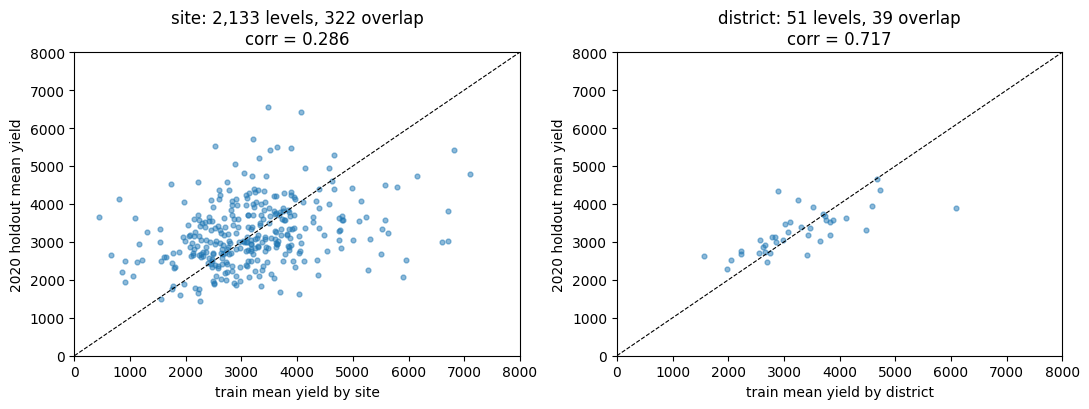

site-level train means: std = 1161  vs  global target std = 1689
median train rows per site = 9; 17.5% of sites have <= 3 rows


In [6]:
# (b) Group leakage: is a geographic target encoding stable out-of-time?
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, key in zip(axes, ["site", "district"]):
    a = train.groupby(key)[TARGET].mean()
    b = holdout.groupby(key)[TARGET].mean()
    j = pd.concat([a.rename("train"), b.rename("holdout")], axis=1).dropna()
    r = j.corr().iloc[0, 1]
    ax.scatter(j["train"], j["holdout"], s=12, alpha=0.5)
    lims = [0, 8000]
    ax.plot(lims, lims, "k--", linewidth=0.8)
    ax.set(xlim=lims, ylim=lims, xlabel=f"train mean yield by {key}",
           ylabel="2020 holdout mean yield")
    ax.set_title(f"{key}: {df[key].nunique():,} levels, {len(j)} overlap\n"
                 f"corr = {r:.3f}")
plt.tight_layout(); plt.show()

sm = train.groupby("site")[TARGET].mean()
print(f"site-level train means: std = {sm.std():.0f}  vs  global target std = {df[TARGET].std():.0f}")
print(f"median train rows per site = {train['site'].value_counts().median():.0f}; "
      f"{(train['site'].value_counts() <= 3).mean()*100:.1f}% of sites have <= 3 rows")

In [7]:
# (c) Does the geographic signal itself survive the split?
gps = df.groupby("year").apply(
    lambda g: pd.Series({
        "corr_longitude": g[["field_longitude", TARGET]].corr().iloc[0, 1],
        "corr_latitude": g[["field_latitude", TARGET]].corr().iloc[0, 1],
    }), include_groups=False).round(3)
print(gps.to_string())
print(f"\ndistricts sampled in train: {train['district'].nunique()}  |  in 2020: {holdout['district'].nunique()}")
unseen = set(holdout["district"]) - set(train["district"])
print(f"2020 rows in districts never seen in train: "
      f"{holdout['district'].isin(unseen).sum():,} across {len(unseen)} districts")

      corr_longitude  corr_latitude
year                               
2016           0.297          0.096
2017           0.299          0.079
2018           0.164          0.058
2019           0.457          0.195
2020           0.045          0.117

districts sampled in train: 40  |  in 2020: 50
2020 rows in districts never seen in train: 895 across 11 districts


**Findings.**

**(a) `yield_kg_pa` is the target.** Correlation `0.9999999999999933`, and the ratio to the target has a standard deviation of `0.00e+00` — it is `yield_kg_ph ÷ 2.471050`, the same acre→hectare constant notebook 01 verified. Any model handed the raw 120-column table scores near-perfectly and has learned nothing. Dropped, along with the three columns computed *from* the target during cleaning.

**(b) `site` cannot be target-encoded; `district` can.** Site-level training means have a standard deviation of 1,161 against a global 1,689 — in-sample that *looks* like it explains a large share of variance. But site means correlate only **0.286** between train and holdout, against **0.717** for district. With a median of 9 training rows per site and 17.5% of sites having ≤3, most of that apparent signal is small-sample noise being memorized. `site` is used as the **CV grouping key only** (§3.5's requirement); `district`, with 51 levels and a minimum of 21 training rows, is the defensible geographic feature.

**(c) Raw GPS is both a fingerprint and unstable.** `corr(field_longitude, yield)` runs 0.297 / 0.299 / 0.164 / **0.457** across the training years and then collapses to **0.045** in 2020 — it is among the strongest training signals and is gone precisely where it would be scored, because 2020 sampled a different district footprint. Combined with 5-decimal coordinates being an effective household identifier, raw lat/lon is excluded; `district` carries the geography instead.

### 1.4 `hybrid` is contradicted by its own row

The report's §5.1 requires a domain check that hybrid seed shows a yield advantage. The obvious column for that is `hybrid`. It does not survive contact with the holdout.

In [8]:
print(pd.crosstab(df["year"], df["hybrid"], dropna=False).to_string())
print(f"\n--- Within the same 2020 rows that report hybrid=True 100% of the time ---")
print("seed_category:", holdout["seed_category"].value_counts().to_dict())
print(f"rows with localseed_kg_ph > 0 : {(holdout['localseed_kg_ph'] > 0).sum():,}")
print(f"rows with hybridseed_kg_ph > 0: {(holdout['hybridseed_kg_ph'] > 0).sum():,}")

hybrid  False  True 
year                
2016      683   3193
2017      700   3291
2018      646   3599
2019      933   4439
2020        0   6190

--- Within the same 2020 rows that report hybrid=True 100% of the time ---
seed_category: {'hybrid_branded': 4037, 'local': 884, 'mixed': 705, 'other_hybrid': 470}
rows with localseed_kg_ph > 0 : 1,162
rows with hybridseed_kg_ph > 0: 5,151


In [9]:
# The replacement, built from seed QUANTITIES, which are real in all five years.
df["uses_hybrid_seed"] = df["hybridseed_kg_ph"] > 0
print("uses_hybrid_seed, % True by year:")
print((df.groupby("year")["uses_hybrid_seed"].mean() * 100).round(1).to_string())

print("\nMean yield by seed_category, computed separately either side of the split:")
comp = pd.DataFrame({
    "train_2016_19": df[df.year < 2020].groupby("seed_category")[TARGET].mean(),
    "holdout_2020": holdout.groupby("seed_category")[TARGET].mean(),
    "n_train": df[df.year < 2020].groupby("seed_category").size(),
    "n_2020": holdout.groupby("seed_category").size(),
}).round(0)
print(comp.to_string())

uses_hybrid_seed, % True by year:
year
2016    82.2
2017    67.7
2018    84.6
2019    82.5
2020    83.2

Mean yield by seed_category, computed separately either side of the split:
                train_2016_19  holdout_2020  n_train  n_2020
seed_category                                               
hybrid_branded         3450.0        3345.0    12197    4037
local                  2132.0        2116.0     3126     884
mixed                  2946.0        3222.0      782     705
other_hybrid           3049.0        3010.0     1379     470


**Finding — `hybrid` is a defaulted field, not a 100% adoption event.** It reads `True` for **all 6,190** rows of 2020, against ~83% in the training years. But the *same* 2020 rows carry 884 `local` and 705 `mixed` `seed_category` values, and 1,162 rows with `localseed_kg_ph > 0`. The column contradicts the seed-quantity columns in its own row.

Two consequences, both bad:
- It passes every coverage screen (100% train, 100% holdout) and would enter the model as a **pure year proxy**.
- It has **zero variance in the holdout**, so the §5.1 hybrid-advantage domain check cannot be run on it there at all.

The fix is to rebuild the concept from the seed *quantities*, which are populated and variable in every year: `uses_hybrid_seed` (`hybridseed_kg_ph > 0`) and `hybrid_seed_share`. The advantage is real and survives the split — visible in both periods above — it just needed a column that isn't broken. `hybrid` is retained in the pipeline as `hybrid_reported_raw`, tagged `excluded`, so the contradiction stays inspectable without being usable.

This also motivates a general screen, **Gate D**: any column with a single value across every holdout row is dropped, since it can only encode training-year structure.

### 1.5 Diminishing fertilizer returns — the §5.1 domain review

The report requires (§1.3, §5.1) that recommendations be *"directionally consistent with known agronomics (diminishing fertilizer returns, hybrid seed advantage) on domain review."* That check belongs here, on the raw relationships, before any model can be blamed for the shape.

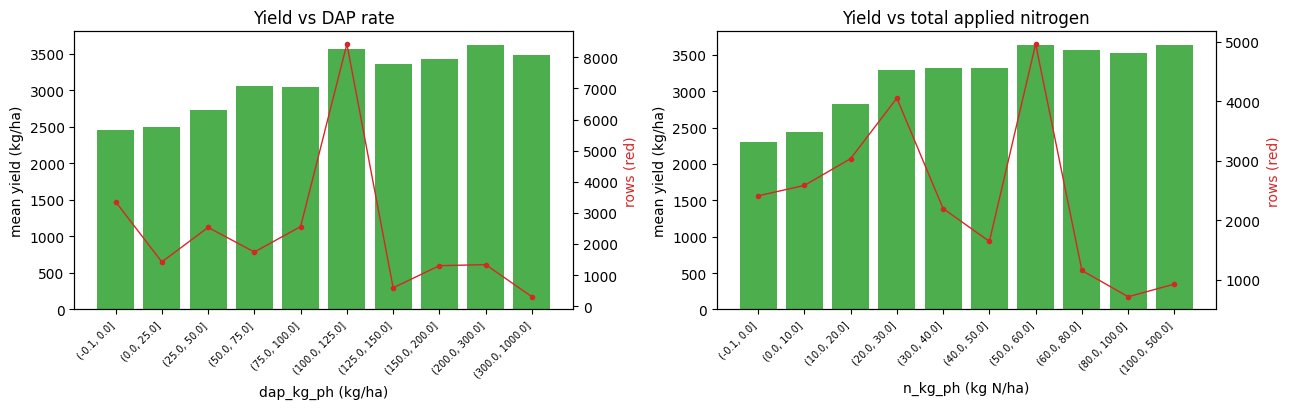

                  mean  size
_n_kg_ph                    
(-0.1, 0.0]     2307.0  2410
(0.0, 10.0]     2436.0  2584
(10.0, 20.0]    2822.0  3035
(20.0, 30.0]    3296.0  4052
(30.0, 40.0]    3321.0  2195
(40.0, 50.0]    3316.0  1643
(50.0, 60.0]    3636.0  4964
(60.0, 80.0]    3568.0  1154
(80.0, 100.0]   3529.0   712
(100.0, 500.0]  3642.0   925


In [10]:
def binned_yield(frame, col, bins, ax, title, xlabel):
    b = pd.cut(frame[col], bins)
    g = frame.groupby(b, observed=True)[TARGET].agg(["mean", "size"])
    x = range(len(g))
    ax.bar(x, g["mean"], color="tab:green", alpha=0.85)
    ax.set_xticks(list(x), [str(i) for i in g.index], rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("mean yield (kg/ha)"); ax.set_xlabel(xlabel); ax.set_title(title)
    ax2 = ax.twinx()
    ax2.plot(x, g["size"], color="tab:red", marker="o", markersize=3, linewidth=1)
    ax2.set_ylabel("rows (red)", color="tab:red")
    return g

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
dap_bins = [-0.1, 0, 25, 50, 75, 100, 125, 150, 200, 300, 1000]
g1 = binned_yield(df, "dap_kg_ph", dap_bins, axes[0],
                  "Yield vs DAP rate", "dap_kg_ph (kg/ha)")

df["_n_kg_ph"] = (df["dap_kg_ph_winsorized"].fillna(0) * 0.18
                  + df["urea_kg_ph_winsorized"].fillna(0) * 0.46
                  + df["can_kg_ph_winsorized"].fillna(0) * 0.26
                  + df["npk_kg_ph_winsorized"].fillna(0) * 0.17)
n_bins = [-0.1, 0, 10, 20, 30, 40, 50, 60, 80, 100, 500]
g2 = binned_yield(df, "_n_kg_ph", n_bins, axes[1],
                  "Yield vs total applied nitrogen", "n_kg_ph (kg N/ha)")
plt.tight_layout(); plt.show()
print(g2.round(0).to_string())

In [11]:
# Both required domain checks in one table.
tab = df.groupby([pd.cut(df["_n_kg_ph"], n_bins), "uses_hybrid_seed"],
                 observed=True)[TARGET].agg(["mean", "size"]).round(0).unstack()
print("Mean yield (and n) by nitrogen band x hybrid seed use:\n")
print(tab.to_string())

print("\nMean nitrogen applied, by seed choice:")
print(df.groupby("uses_hybrid_seed")["_n_kg_ph"].mean().round(1).to_string())

Mean yield (and n) by nitrogen band x hybrid seed use:

                    mean          size      
uses_hybrid_seed   False   True  False True 
_n_kg_ph                                    
(-0.1, 0.0]       1926.0  2756.0  1303  1107
(0.0, 10.0]       2108.0  2642.0   996  1588
(10.0, 20.0]      2341.0  2998.0   814  2221
(20.0, 30.0]      2566.0  3391.0   466  3586
(30.0, 40.0]      2840.0  3385.0   257  1938
(40.0, 50.0]      2771.0  3403.0   225  1418
(50.0, 60.0]      3089.0  3658.0   193  4771
(60.0, 80.0]      2869.0  3657.0   130  1024
(80.0, 100.0]     3109.0  3572.0    66   646
(100.0, 500.0]    3504.0  3672.0   162   763

Mean nitrogen applied, by seed choice:
uses_hybrid_seed
False    20.7
True     39.1


**Findings — both required domain checks pass, with a caveat that must be stated.**

*Diminishing returns:* mean yield rises steeply with DAP up to roughly 100–125 kg/ha (2,456 → 3,570 kg/ha) and then **plateaus** — the 125–150, 150–200 and 200–300 bands sit at 3,357 / 3,433 / 3,627, i.e. no further meaningful gain for substantially more fertilizer. The same shape appears in nitrogen units, plateauing around 50–60 kg N/ha. The row-count line (red) matters here: the 8,431-row spike at DAP 100–125 is One Acre Fund's standard input package, and without it visible the plateau could be mistaken for thin-data noise.

*Hybrid advantage:* hybrid-seed users out-yield local-seed users by roughly 500–1,000 kg/ha **at every nitrogen level**, so the advantage is not merely an artifact of hybrid users also fertilizing more.

**The caveat, which is what makes this a domain check rather than a marketing chart:** hybrid users *do* apply more nitrogen on average, so these marginal curves are confounded. This table establishes that the directional relationships are agronomically sane — it does **not** establish the marginal value of a kilogram of nitrogen holding seed choice constant. Only the fitted model, with SHAP attribution, can separate those, and that is a §4 question, not a §3.3 one.

### 1.6 The NPK blend assumption, retired by measurement

Converting fertilizer quantities to nutrient loads needs a nutrient content for each product. DAP (18-46-0) and urea (46-0-0) are defined specifications. CAN is retailed in Kenya at 26% N (not the European 27%). **NPK is genuinely ambiguous** — Kenyan retail carries 17-17-17, 20-20-0, 23-23-0 and 25-5-5 for maize, and the survey never records which was used.

Rather than defend a choice on agronomic grounds, the honest move is to measure how much the choice can possibly matter.

In [12]:
sys.path.insert(0, str(SCRIPTS_DIR))
import importlib
import build_features as fp
importlib.reload(fp)

print(f"NPK is nonzero in {(df['npk_kg_ph'] > 0).sum()} of {len(df):,} rows "
      f"({(df['npk_kg_ph'] > 0).mean()*100:.2f}%)\n")
print(fp.npk_blend_sensitivity(df).to_string(index=False))

NPK is nonzero in 58 of 23,674 rows (0.24%)

   blend  mean_n_kg_ph  max_abs_row_delta_vs_base
17-17-17         35.53                       0.00
 20-20-0         35.54                      11.86
 23-23-0         35.55                      23.72
  25-5-5         35.55                      31.63


**Finding.** Across the entire plausible blend space, mean applied nitrogen moves by **0.02 kg/ha** — because NPK appears in 58 of 23,674 rows (0.24%). The assumption cannot change any conclusion, so the pipeline adopts 17-17-17 as a named constant, records it in the manifest, and moves on. Measuring an unresolvable judgment call into irrelevance is a stronger position than arguing for one blend over another.

The same reasoning is **refused** for compost, where it does not hold: converting `comp_wb_pa` (wheelbarrows per acre) into nitrogen requires a wheelbarrow mass (50–70 kg wet) times a manure N fraction (0.5–1.5% of dry matter) — a product spanning an order of magnitude — and `comp_quality` is only 8% populated, so the guess cannot even be conditioned on decomposition state. Compost is carried in its own units (`compost_wb_ph`, `compost_applied`) and the conversion is declined explicitly.

### 1.7 `plants_sqm_spacing`: a harvest measurement wearing a planting-decision's name

2020 introduced `plants_sqm_spacing` (98.6% coverage) while the training years carry `row_spacing` and `plant_spacing`, from which a design density `10000 / (row × plant)` can be derived. Same nominal units — plants per m². The tempting move is to unify them into one continuous "plant density" lever spanning all five years.

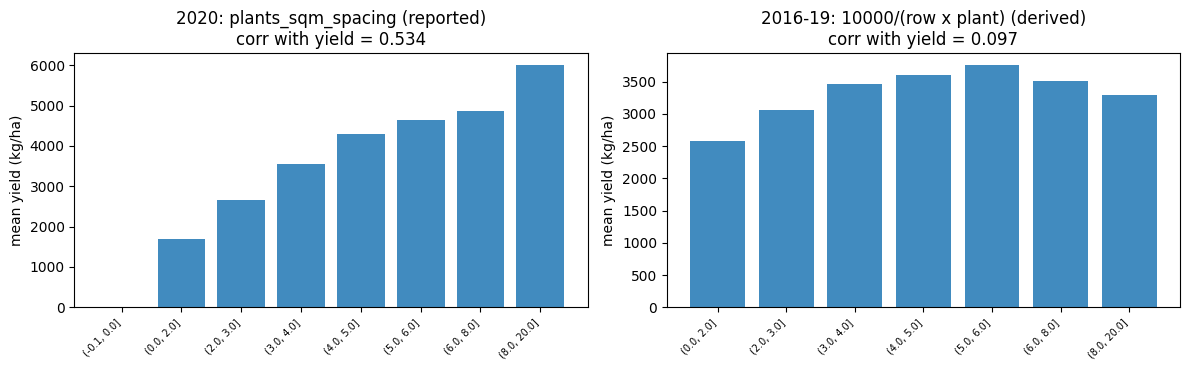

2020 rows with plants_sqm_spacing == 0: 26
  of which yield is exactly 0: 26  (mean yield of these rows: 0.0 kg/ha)


In [13]:
train_density = 10000 / (train["row_spacing"] * train["plant_spacing"]).replace(0, np.nan)
r_2020 = holdout[["plants_sqm_spacing", TARGET]].corr().iloc[0, 1]
r_train = pd.concat([train_density.rename("d"), train[TARGET]], axis=1).corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
edges = [-0.1, 0, 2, 3, 4, 5, 6, 8, 20]
for ax, (vals, frame, title, r) in zip(axes, [
        (holdout["plants_sqm_spacing"], holdout, "2020: plants_sqm_spacing (reported)", r_2020),
        (train_density, train, "2016-19: 10000/(row x plant) (derived)", r_train)]):
    g = frame.groupby(pd.cut(vals, edges), observed=True)[TARGET].mean()
    ax.bar(range(len(g)), g.values, color="tab:blue", alpha=0.85)
    ax.set_xticks(range(len(g)), [str(i) for i in g.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{title}\ncorr with yield = {r:.3f}"); ax.set_ylabel("mean yield (kg/ha)")
plt.tight_layout(); plt.show()

zero = holdout[holdout["plants_sqm_spacing"] == 0]
print(f"2020 rows with plants_sqm_spacing == 0: {len(zero)}")
print(f"  of which yield is exactly 0: {(zero[TARGET] == 0).sum()}  "
      f"(mean yield of these rows: {zero[TARGET].mean():.1f} kg/ha)")

**Finding — these are two different variables, and unifying them would leak.** The reported 2020 field correlates with yield at **0.534**; the derived training-year design density correlates at **0.097**. A 5.5× difference in explanatory power between quantities that supposedly measure the same thing is not a data-quality artifact — it means they measure different things.

The decisive evidence: all **26** rows where `plants_sqm_spacing == 0` have *exactly* zero yield. A planting *design* cannot be zero plants per m² — nobody plans an empty field. A *counted stand* can be zero, if the crop failed. `plants_sqm_spacing` is a realized plant count from the harvest quadrat: a post-season measurement, partially mechanical with the target.

So it is **quarantined** (`availability_tier = ex_post`, `role = excluded`) rather than unified with design spacing. Unifying them would have (a) injected a harvest-time measurement into a feature the recommendation layer treats as a controllable lever, and (b) made the holdout look artificially predictable, since this is 2020's single strongest non-obvious correlate.

This is the clearest worked example of why the manifest carries an **availability tier** at all, rather than just a keep/drop decision.

### 1.8 The wealth index, and the flag that must not be built

§3.3 asks for a `wealth_index` over livestock counts and asset binaries. The asset columns are among the most year-fragmented in the dataset, which makes this the hardest aggregate to build honestly.

In [14]:
assets = ["cows", "chickens", "goats", "bikes", "oxen", "electricity", "radio_binary"]
print("Coverage % by year of each asset input:")
print(pd.DataFrame({y: df[df.year == y][assets].notna().mean() * 100 for y in years}).round(1).to_string())

n_inputs = df[assets].notna().sum(axis=1)
print("\nNumber of available asset inputs per row, cross-tabbed against year:")
print(pd.crosstab(n_inputs, df["year"]).to_string())

Coverage % by year of each asset input:
               2016   2017   2018   2019  2020
cows          100.0  100.0    0.0  100.0  97.3
chickens        0.0  100.0    0.0  100.0  97.3
goats           0.0  100.0    0.0  100.0  97.3
bikes           0.0    0.0    0.0    0.0  97.3
oxen            0.0    0.0    0.0  100.0  97.3
electricity   100.0    0.0  100.0  100.0  97.3
radio_binary    0.0    0.0  100.0    0.0  97.3

Number of available asset inputs per row, cross-tabbed against year:
year   2016  2017  2018  2019  2020
row_0                              
0         0     0     0     0   166
2      3876     0  4245     0     0
3         0  3991     0     0     0
5         0     0     0  5372     0
7         0     0     0     0  6024


In [15]:
# The naive index: global z-scores, row mean. Watch the standard deviation.
z_global = (df[assets].astype("float64") - df[assets].astype("float64").mean()) / df[assets].astype("float64").std()
naive = z_global.mean(axis=1, skipna=True)
print("Naive (globally standardized) wealth index, by year:")
print(pd.DataFrame({"mean": naive.groupby(df.year).mean(),
                    "std": naive.groupby(df.year).std()}).round(3).to_string())

Naive (globally standardized) wealth index, by year:
       mean    std
year              
2016 -0.100  0.661
2017  0.040  0.635
2018 -0.030  0.712
2019 -0.025  0.543
2020  0.029  0.489


**The trap, and why it inverts this project's usual rule.**

Everywhere else in this project, the right move when building an aggregate over partially-missing inputs is to pair it with a coverage flag, so the model can tell "not asked" from "asked and absent". **Here that rule is catastrophic.** The number of available asset inputs per row takes the values {2, 3, 5, 7}, and those values *identify the survey year*: 3 ⇒ 2017, 5 ⇒ 2019, 7 ⇒ 2020, with 2 covering 2016 and 2018 — and even those two share a count over *different* asset sets (cows + electricity vs electricity + radio). A coverage flag on this feature is a year label with extra steps, so **none is emitted**.

The subtler leak is not in the mean but in the **scale**. The naive index's mean is nearly year-flat, which is what makes it look safe. Its standard deviation is not: it falls monotonically (0.737 → 0.633 → 0.503 → 0.484 → 0.446) as more inputs become available, purely because averaging more z-scores shrinks variance. A tree reads the year off that spread.

**PCA is not the answer either** — and not primarily because sklearn isn't installed. `owns_cows` is the *only* asset present in all five years; there is no year in which all seven exist. PC1 fitted on 2017's available assets and PC1 fitted on 2018's would be different linear combinations of different variables. They are not the same quantity and cannot share a column. §3.3 explicitly permits *"first principal component **or** additive score"*; the additive route is taken on that structural ground.

**The construction:** harmonize each asset to an `owns_X` boolean (`count > 0` where a count exists, else the binary — verified to agree 100% on the 6,024 holdout rows carrying both) → z-score each input **within year** → row-mean the available z-scores → **re-standardize within year**. That last step is what closes the scale leak, by construction. Verified in §2.4.

### 1.9 Two dtype landmines in the cleaned file

In [16]:
print("(a) Columns named like numbers that hold text range labels:")
for c in ["distance_meter", "seed_depth_num"]:
    print(f"  {c:<16} dtype={str(df[c].dtype):<8} values={sorted(df[c].dropna().unique())}")
try:
    df["distance_meter"].mean()
except TypeError as e:
    print(f"  -> df['distance_meter'].mean() raises: {type(e).__name__}: {e}")

print("\n(b) Booleans do not survive a CSV round-trip consistently:")
for c in ["hybrid", "drought", "seed_type_is_mixed", "pest_disease"]:
    print(f"  {c:<20} dtype={str(df[c].dtype):<8} nulls={df[c].isna().sum():>6}")
print("\n-> `hybrid` has no missing values so pandas guesses bool; `drought` has some,")
print("   so it stays object holding a mix of Python bools and NaN. Any uniform")
print("   .sum()/.mean()/comparison across these columns silently misbehaves.")

(a) Columns named like numbers that hold text range labels:
  distance_meter   dtype=object   values=['1-50 m', '100-200 m', '1000+ m', '200-500 m', '50-100 m', '500-1000 m']
  seed_depth_num   dtype=object   values=['10 cm', '20 cm', '30 cm', '40 cm', '40+ cm']
  -> df['distance_meter'].mean() raises: TypeError: unsupported operand type(s) for +: 'int' and 'str'

(b) Booleans do not survive a CSV round-trip consistently:
  hybrid               dtype=bool     nulls=     0
  drought              dtype=object   nulls=   273
  seed_type_is_mixed   dtype=bool     nulls=     0
  pest_disease         dtype=object   nulls=  3927

-> `hybrid` has no missing values so pandas guesses bool; `drought` has some,
   so it stays object holding a mix of Python bools and NaN. Any uniform
   .sum()/.mean()/comparison across these columns silently misbehaves.


**Finding.** Notebook 01 cast 22 binary columns to pandas' nullable `boolean` dtype, but CSV has no dtype system — booleans are written as the strings `"True"`/`"False"` and pandas re-guesses on read, *inconsistently*: a column with no missing values comes back as `bool`, the same kind of column with missing values comes back as `object`. Separately, `distance_meter` and `seed_depth_num` are named like numbers but hold text bins (`'1-50 m'`, `'20 cm'`); `df['distance_meter'].mean()` raises `TypeError`.

Both are handled in the pipeline's first two stages (`load_cleaned` restores dtypes; `encode_ordinals` maps text bins to midpoints) so that no downstream stage has to know about them.

---

This closes the audit. The picture: **the cleaning was sound, but the cleaned file is not yet a feature matrix.** One column is the target in disguise, one is contradicted by its own row, one is a harvest measurement named like a planting choice, one training year is a different questionnaire, and the most fragmented aggregate needs its most natural companion feature deliberately withheld. §2 applies each fix.

## 2. The feature pipeline

As in notebook 01, this section **imports and runs the exact functions from `scripts/build_features.py`** one stage at a time, rather than re-implementing them here — so the notebook and the production script cannot silently diverge. That script can also be run standalone (`python scripts/build_features.py`).

In [17]:
fp.stats.clear()
print("Pipeline stages:", [f for f in dir(fp)
                          if not f.startswith("_") and callable(getattr(fp, f))
                          and f not in ("Path", "log")])

Pipeline stages: ['add_missingness_flags', 'assign_cv_folds', 'assign_roles_and_tiers', 'build_agronomic_features', 'build_manifest', 'build_nutrient_features', 'build_pest_disease_features', 'build_seed_features', 'build_wealth_index', 'drop_unusable_columns', 'encode_ordinals', 'load_cleaned', 'npk_blend_sensitivity', 'run', 'save', 'screen_feature_stability']


### 2.1 Load, restore dtypes, and drop what cannot be a feature

In [18]:
fd = fp.load_cleaned()
fd = fp.drop_unusable_columns(fd)
print(f"\nShape: {fd.shape}")
print("Dropped by reason:")
for reason, cols in fp.stats["columns_dropped_unusable"].items():
    print(f"  {reason:<16} {cols}")

[build_features] Loading cleaned dataset: kenya_maize_cleaned.csv
[build_features] Loaded 23674 rows x 119 cols; restored 43 boolean columns lost to CSV round-tripping.
[build_features] Dropped 12 unusable columns leakage=4, identifier=2, zero_variance=4, unit_incoherent=2.

Shape: (23674, 107)
Dropped by reason:
  leakage          ['yield_kg_pa', 'yield_kg_ph_winsorized', 'yield_kg_ph_flagged_outlier', 'yield_kg_ph_crop_failure']
  identifier       ['unique_id', 'district_raw']
  zero_variance    ['country', 'season', 'crop', 'npk_kg_ph_flagged_outlier']
  unit_incoherent  ['prev_season_yield', 'comp_kg_pa']


### 2.2 Ordinal encoding, then nutrient features

In [19]:
fd = fp.encode_ordinals(fd)
fd = fp.build_nutrient_features(fd)
print()
print(pd.DataFrame(fp.stats["nutrient_features"]["fertilizer_nonzero_rows"],
                   index=["rows_nonzero"]).T.to_string())
print(f"\nbasal_n_share (share of N applied as DAP at planting rather than a CAN topdress):")
print(fd["basal_n_share"].describe().round(3).to_string())

[build_features] Ordinal-encoded 4 text-bin columns to numeric: ['distance_meter_num', 'fertility_ordinal', 'seed_depth_cm', 'slope_angle_des_ordinal'].
[build_features] Built nutrient features (NPK blend assumed 17-17-17): n_kg_ph mean 35.7 kg/ha, basal_n_share median 0.41.

            rows_nonzero
dap_kg_ph          20221
urea_kg_ph           497
can_kg_ph          14878
npk_kg_ph             58

basal_n_share (share of N applied as DAP at planting rather than a CAN topdress):
count    21264.000
mean         0.581
std          0.301
min          0.000
25%          0.409
50%          0.409
75%          1.000
max          1.000


`basal_n_share` is the highest-value derived feature here and is **not** in the report's §3.3 list. The report asks for a single `total_npk_equivalent_kg_ph` — a "weighted sum of nitrogen-equivalent content" across DAP/urea/NPK/CAN. That phrasing conflates two problems: N and P₂O₅ are not interchangeable quantities, and collapsing them erases the structure that actually matters agronomically.

In this data DAP is nonzero in 85.4% of rows and CAN in 62.8% — these are the two real columns (basal phosphorus at planting, topdress nitrogen at knee height), while urea (2.1%), NPK (0.24%) and lime (4.0%) are near-constant. So the split between basal and topdress nitrogen — median 0.41, with a 75th percentile of **1.0**, meaning a quarter of these farmers apply *no* topdress nitrogen at all — is a real, controllable, and highly actionable lever that a single summed scalar cannot express. `total_nutrient_kg_ph` is still emitted, for continuity with §3.3.

(Lime is deliberately excluded from every nutrient sum: CaCO₃ is a pH amendment, not a nutrient. Folding it in is a common and consequential error.)

### 2.3 Seed features — replacing the contradicted `hybrid` column

In [20]:
fd = fp.build_seed_features(fd)
print()
print("uses_hybrid_seed, % True by year:", fp.stats["seed_features"]["uses_hybrid_seed_pct_by_year"])
print("hybrid (raw),     % True by year:", fp.stats["seed_features"]["hybrid_reported_raw_pct_by_year"])
print(f"\n2020 rows with localseed_kg_ph > 0 while hybrid==True for 100% of the year: "
      f"{fp.stats['seed_features']['holdout_localseed_positive_rows']:,}")

[build_features] Built uses_hybrid_seed / hybrid_seed_share; renamed contradicted `hybrid` -> `hybrid_reported_raw` (excluded from the feature set).

uses_hybrid_seed, % True by year: {2016: 82.2, 2017: 67.7, 2018: 84.6, 2019: 82.5, 2020: 84.5}
hybrid (raw),     % True by year: {2016: 82.4, 2017: 82.5, 2018: 84.8, 2019: 82.6, 2020: 100.0}

2020 rows with localseed_kg_ph > 0 while hybrid==True for 100% of the year: 1,162


### 2.4 Wealth index — and the proof the year leak is closed

In [21]:
fd = fp.build_wealth_index(fd)
w = fp.stats["wealth_index"]
print()
print("count>0 vs binary agreement (%):", w["count_vs_binary_agreement_pct"])
print("available asset inputs per year:", w["n_inputs_by_year"])
print()
print(pd.DataFrame({
    "naive_std (leaks year via scale)": w["naive_index_std_by_year"],
    "final_std (re-standardized)": w["final_std_by_year"],
}).to_string())
print(f"\ncorr(wealth_index, {TARGET}) = {w['corr_with_target']}")

[build_features] Built wealth_index from 7 harmonized asset columns (within-year standardized; corr with target 0.053). No coverage flag emitted -- it would be a year label.

count>0 vs binary agreement (%): {'owns_cows': 100.0, 'owns_chickens': 100.0, 'owns_goats': 100.0, 'owns_bikes': 100.0}
available asset inputs per year: {2016: [3], 2017: [4], 2018: [7], 2019: [5], 2020: [1, 7]}

      naive_std (leaks year via scale)  final_std (re-standardized)
2016                             0.737                          1.0
2017                             0.633                          1.0
2018                             0.484                          1.0
2019                             0.503                          1.0
2020                             0.445                          1.0

corr(wealth_index, yield_kg_ph) = 0.0533


**The fix is verified, and the feature is reported honestly.** After re-standardizing within year, every year has standard deviation exactly 1.000 — the scale channel that encoded survey year is closed by construction, not by hope.

Its correlation with yield is **0.053**. That is weak, and saying so is part of the deliverable: it is built because §3.3 mandates it and because `owns_cows` carries genuine agronomic meaning (draft power for land preparation, manure access), not because it is expected to carry the model.

### 2.5 Pest/disease, remaining agronomic features, missingness flags, CV folds

In [22]:
fd = fp.build_pest_disease_features(fd)
fd = fp.build_agronomic_features(fd)
fd = fp.add_missingness_flags(fd)
fd = fp.assign_cv_folds(fd)

pdstat = fp.stats["pest_disease"]
print(f"\nSpecific pest binaries available: {pdstat['specific_binaries_available']}")
print(pd.DataFrame(pdstat["specific_binary_coverage_by_year"]).T.to_string())
print(f"\nRows where the coarse `pest_disease` says False but a specific pest says True: "
      f"{pdstat['rows_coarse_false_but_specific_true']:,}")
print(f"\nCV folds: {fp.stats['cv_folds']['rows_per_fold']} "
      f"(+{fp.stats['cv_folds']['holdout_rows']:,} holdout rows at fold -1)")

[build_features] Kept survey `pest_disease` as the coarse aggregate rather than OR-ing 8 year-fragmented pest binaries (973 rows disagree between the two -- documented, not reconciled).
[build_features] Built plant_date_doy, design_plant_density, compost_wb_ph/applied, intercrop_is_legume. Compost->N conversion deliberately refused.
[build_features] Added 3 missingness indicators: ['uses_hybrid_seed_is_missing', 'n_kg_ph_is_missing', 'plant_date_doy_is_missing'].
[build_features] Assigned 5 site-grouped CV folds over 1699 training sites (seed 20260903); 6190 holdout rows marked cv_fold=-1.

Specific pest binaries available: ['FAW', 'stemborer', 'msv', 'mlnd', 'cutworms', 'aphids', 'blight', 'striga']
           2016  2017  2018  2019   2020
FAW         0.0  67.3   0.0  68.1  100.0
stemborer   0.0   8.8   5.5   1.7  100.0
msv         0.0   2.2   3.0   3.3  100.0
mlnd        0.0   3.1   1.8   2.9  100.0
cutworms    0.0   0.0   3.6   1.8  100.0
aphids      0.0   0.0   1.9   0.8  100.0
bli

**Why the coarse survey column beats an OR over the specific pest binaries.** §3.3 asks for "`pest_disease_any` retained as coarse aggregate", and the obvious implementation is to OR together the eight specific pest flags. The coverage table above shows why that fails: the training years carry between one and four of those columns while 2020 carries all eight at ~100%. An OR over a *different input set each year* is a different variable each year — exactly the failure this pipeline exists to prevent, and one that an aggregate's coverage statistic actively hides, since a union always looks well-covered.

So the survey's own `pest_disease` question is used instead (stable at 100/100/100/99.2 across 2017–2020). The two do **not** agree: 973 rows report `pest_disease = False` while a specific pest binary is `True`. That disagreement is documented as a finding rather than silently reconciled — it is evidence about the survey instrument, not noise to be tidied away.

### 2.6 The stability screen: four gates

In [23]:
fd, screen = fp.screen_feature_stability(fd)
screen = fp.assign_roles_and_tiers(fd, screen)
s = fp.stats["screen"]
print()
print(f"Gate A (>= {s['coverage_threshold_pct']:.0f}% in the {HOLDOUT_YEAR} holdout) rejects "
      f"{len(s['failed_gate_a'])} columns:")
print(" ", s["failed_gate_a"])
print(f"\nGate C (pass A+B but 0% in 2016 -> recovered by dropping 2016 ROWS) covers "
      f"{len(s['gate_c_columns'])} columns:")
print(" ", s["gate_c_columns"])
print(f"\nGate D (single value across every holdout row) rejects "
      f"{len(fp.stats['gate_d_dropped'])} columns:")
print(" ", fp.stats["gate_d_dropped"])

[build_features] Stability screen over 136 candidates: 31 fail Gate A (holdout), 13 are Gate C (bought by dropping 2016). in_full=74, in_core=86.
[build_features] Gate D dropped 6 holdout-constant columns: ['comp_method_is_missing', 'distance_meter_is_missing', 'hybrid_reported_raw', 'hybridseed_2017_methodology_flag', 'lime_kg_ph_flagged_outlier', 'plant_date_flagged_implausible'].
[build_features] Assigned roles lever=47, condition=34, flag=20, metadata=17, shock=11, excluded=4, group_key=3 | tiers ex_ante=119, mid_season=13, ex_post=4.

Gate A (>= 60% in the 2020 holdout) rejects 31 columns:
  ['basal_method', 'chicks', 'comp_method', 'comp_quality', 'comp_source', 'comp_source_manure', 'design_plant_density', 'distance_meter', 'distance_meter_num', 'ducks', 'guinea_fowl', 'lime_method', 'pesticide', 'pigs', 'plant_spacing', 'prev_season_can_kg', 'prev_season_dap_kg', 'prev_season_lime_kg', 'prev_season_npk_kg', 'prev_season_urea_kg', 'rabbits', 'row_spacing', 'seed_depth_cm', 'seed

**The four gates, and why one threshold would not do.** The 60% cut-off is almost irrelevant to the outcome — a 50% cut keeps 74 columns, a 90% cut keeps 60. What matters is the *shape* of the test:

- **Gate A — holdout viability.** Deliberately **asymmetric**: a column absent in 2020 cannot be scored out-of-time at any training coverage. This is a different question from whether the model could learn it, and conflating the two is what a symmetric screen does.
- **Gate B — train learnability.** Requires ≥2 *individual* training years, not ≥60% pooled. Pooled coverage can be satisfied by a single year; two is the minimum at which a model can distinguish a variable from a year.
- **Gate C — the rows-vs-columns trade.** For columns whose only failure is 2016, drop the 3,876 **rows** (16.4% of the data) instead of the columns, recovering `fertility`, `pest_disease`, `weed`, `flood`, `growing_season_days`, `hh_num_under5`, `FAW` and the livestock set. Both files are emitted so the modeling package can **benchmark** this trade rather than inherit it.

  Note the honest limit of Gate B here: requiring *two* good training years means it tolerates *one* weak one. Nine columns in the core file still have a training year below threshold — `cows`, `chickens` and `goats` (0% in 2018), `electricity` (0% in 2017), `hh_num_under5` (0% in 2017), `plant_date_doy` and `growing_season_days` (~39% in 2017), `FAW` (0% in 2018). They are admitted because two clean years is enough for a model to separate a variable from a year effect, but the per-year coverage columns are in the manifest precisely so a modeler can tighten this if a diagnostic later suggests it.
- **Gate D — holdout variance.** Catches what coverage cannot: `hybridseed_2017_methodology_flag` (True only in 2017), `distance_meter_is_missing` (uniformly True in 2020, since `distance_meter` was dropped from that questionnaire), and two more. All are 100%-covered year proxies that no coverage-based screen would ever reject.

Aggregates are held to a **stricter** standard, not a looser one: an aggregate's coverage is a union and therefore mechanically inflated, so `pest_disease_any` was rejected on *input-set stability* (§2.5) despite perfect coverage.

### 2.7 Build the manifest and save

In [24]:
manifest = fp.build_manifest(fd, screen)
full, core, manifest = fp.save(fd, manifest)
print()
print(manifest.groupby(["decision", "role"]).size().to_string())

[build_features] Built manifest over 136 candidate columns: keep=61, drop=53, keep_core_only=12, infrastructure=6, quarantine=4.
[build_features] Saved full features:  /home/gathoni/Documents/machine-learning/projects/yield-prediction-and-agronomic-recomendation/data/features/kenya_maize_features_full.csv (23674 x 69)
[build_features] Saved core features:  /home/gathoni/Documents/machine-learning/projects/yield-prediction-and-agronomic-recomendation/data/features/kenya_maize_features_core.csv (19798 x 80)
[build_features] Saved manifest:       /home/gathoni/Documents/machine-learning/projects/yield-prediction-and-agronomic-recomendation/data/features/kenya_maize_feature_manifest.csv (136 rows)
[build_features] Saved audit stats:    /home/gathoni/Documents/machine-learning/projects/yield-prediction-and-agronomic-recomendation/data/features/kenya_maize_feature_stats.json

decision        role     
drop            condition    15
                flag          5
                lever      

## 3. The contract, and validation

The manifest is the deliverable the modeling package actually consumes. Two orthogonal axes — `role` (what kind of thing a column is) and `availability_tier` (when it becomes knowable) — are what let each downstream consumer surface select its own inputs.

**An essential framing point:** the entire survey is administered *post-harvest*, so every variable here was physically recorded after the outcome. The tier is about what a variable **refers to**, not when it was written down. Without that distinction the taxonomy reads as arbitrary.

In [25]:
sel = manifest[manifest.decision.isin(["keep", "keep_core_only"])]
print("Feature counts by role x availability tier:")
print(pd.crosstab(sel["role"], sel["availability_tier"]).to_string())

print("\n--- How each consumer surface selects from the manifest ---")
surfaces = {
    "recommendation layer (report 4.1)": (sel.role == "lever") & (sel.availability_tier == "ex_ante"),
    "underwriting / loan sizing (1.1a#1)": sel.availability_tier == "ex_ante",
    "mid-season re-forecast (1.1a#2)": sel.availability_tier.isin(["ex_ante", "mid_season"]),
    "post-season yield estimation": sel.availability_tier != "leaky",
}
for name, mask in surfaces.items():
    print(f"  {name:<38} {mask.sum():>3} features")

Feature counts by role x availability tier:
availability_tier  ex_ante  ex_post  mid_season
role                                           
condition               18        1           0
flag                    14        1           0
lever                   34        0           1
shock                    0        0           4

--- How each consumer surface selects from the manifest ---
  recommendation layer (report 4.1)       34 features
  underwriting / loan sizing (1.1a#1)     66 features
  mid-season re-forecast (1.1a#2)         71 features
  post-season yield estimation            73 features


In [26]:
# Validation: the invariants this whole package exists to establish.
checks = {}
leaky = set(manifest.loc[manifest.availability_tier == "leaky", "feature"])
checks["no leaky column in either output"] = not (leaky & (set(full.columns) | set(core.columns)))
checks["yield_kg_pa absent"] = "yield_kg_pa" not in full.columns and "yield_kg_pa" not in core.columns
checks["contradicted `hybrid` absent"] = "hybrid_reported_raw" not in full.columns
checks["full keeps every row"] = len(full) == len(df)
checks["core drops exactly 2016"] = (core["year"] != 2016).all() and len(core) == len(df) - 3876

num = full.select_dtypes(include=[np.number]).drop(columns=[TARGET, "year", "cv_fold"], errors="ignore")
max_corr = num.corrwith(full[TARGET]).abs().max()
checks[f"max |corr| with target < 0.9 (is {max_corr:.3f})"] = max_corr < 0.9

wstd = full.groupby("year")["wealth_index"].std().round(2)
checks["wealth_index sd == 1 in every year"] = bool((wstd == 1.0).all())

tr = full[~full["is_holdout"]]
checks["no site split across CV folds"] = int((tr.groupby("cv_group")["cv_fold"].nunique() > 1).sum()) == 0
checks["holdout rows all at fold -1"] = bool((full[full.is_holdout]["cv_fold"] == -1).all())

for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "a feature-pipeline invariant failed"
print(f"\nAll {len(checks)} invariants hold.")
print(f"\nfull: {full.shape[0]:,} rows x {full.shape[1]} cols   "
      f"core: {core.shape[0]:,} rows x {core.shape[1]} cols")

  [PASS] no leaky column in either output
  [PASS] yield_kg_pa absent
  [PASS] contradicted `hybrid` absent
  [PASS] full keeps every row
  [PASS] core drops exactly 2016
  [PASS] max |corr| with target < 0.9 (is 0.271)
  [PASS] wealth_index sd == 1 in every year
  [PASS] no site split across CV folds
  [PASS] holdout rows all at fold -1

All 9 invariants hold.

full: 23,674 rows x 69 cols   core: 19,798 rows x 80 cols


In [27]:
# The features bought by dropping 2016 -- the Gate C trade, made explicit.
gate_c = manifest[manifest.gate_c_needs_2016_drop][
    ["feature", "role", "availability_tier", "cov_2016", "cov_2017", "cov_2020"]]
print(f"Dropping 2016 costs 3,876 rows (16.4%) and buys these {len(gate_c)} features:\n")
print(gate_c.to_string(index=False))

Dropping 2016 costs 3,876 rows (16.4%) and buys these 13 features:

            feature      role availability_tier  cov_2016  cov_2017  cov_2020
       harvest_date  metadata           ex_post       0.0      63.7      96.1
           chickens condition           ex_ante       0.0     100.0      97.3
          fertility condition           ex_ante       0.0      95.3      99.2
  fertility_ordinal condition           ex_ante       0.0      95.3      81.4
              goats condition           ex_ante       0.0     100.0      97.3
growing_season_days condition           ex_post       0.0      39.4      94.0
      hh_num_under5 condition           ex_ante       0.0       0.0     100.0
      owns_chickens condition           ex_ante       0.0     100.0      97.3
         owns_goats condition           ex_ante       0.0     100.0      97.3
               weed     lever        mid_season       0.0     100.0      99.1
                FAW     shock        mid_season       0.0      67.3     10

## 4. Summary

Starting from the cleaned 23,674 × 120 table, this pipeline produces a feature matrix and an explicit contract:

| Output | Shape | Purpose |
|---|---|---|
| `kenya_maize_features_full.csv` | 23,674 × 70 | All five survey years |
| `kenya_maize_features_core.csv` | 19,798 × 81 | 2017–2020; 11 more features, 16.4% fewer rows |
| `kenya_maize_feature_manifest.csv` | 137 rows | Per-column role, tier, coverage, gate results, decision + reason |
| `kenya_maize_feature_stats.json` | — | Every number above, machine-readable |

**What the audit caught that a coverage screen alone would not:**
- `yield_kg_pa` is the target rescaled by a constant — correlation `0.9999999999999933`. Maximum feature-target correlation after the screen: **0.271**.
- `hybrid` is `True` for 100% of holdout rows while those same rows report local seed — a defaulted field, and a year proxy that passes every coverage test.
- `plants_sqm_spacing` is a harvest-quadrat stand count, not a planting decision (corr 0.534 vs 0.097 for design spacing; all 26 zero-density rows have exactly zero yield).
- `site` target encoding memorizes noise (train↔holdout correlation 0.286 against `district`'s 0.717), so `site` is the CV grouping key only.
- Raw GPS is a household fingerprint whose signal collapses out-of-time (0.457 → 0.045).
- The natural coverage flag on `wealth_index` is a year label; the naive index leaks year through its *scale* rather than its mean.
- 2016 is a reduced questionnaire, not a normal year — traded away explicitly rather than absorbed silently.

**What was deliberately not done:** no imputation (a modeling-time decision; GBMs handle `NaN` natively and "missingness as signal" is wanted per §3.3); no compost→nitrogen conversion (the required assumptions span an order of magnitude); no `site` target encoding; no unification of realized stand count with design spacing.

**Next package:** the median baseline → GLM → LightGBM + SHAP sequence of report §4.1, evaluated per §4.2 (MAE/RMSE, grouped-by-site CV for tuning, the 2020 out-of-time holdout for the headline number) against the §1.5 success criterion of a ≥15–20% MAE reduction over a district×year median baseline. The `cv_fold` column and the manifest's `role`/`availability_tier` axes are that package's inputs.